In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
!pip install --upgrade plotly

Defaulting to user installation because normal site-packages is not writeable


In [11]:
import plotly.express as px

In [12]:
df = pd.read_csv('data/movies.csv')

df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [13]:
df.describe()

,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000
mean,2.904504e+07,57165.484281,21.492301,8.226064e+07,106.875859,6.092172,690.217989
std,4.072239e+07,88694.614033,31.816650,1.628571e+08,22.611935,1.194612,1234.585891
min,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,7.900000e+05,9014.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000
50%,1.500000e+07,14629.000000,12.921594,1.917000e+07,103.000000,6.200000,235.000000
75%,4.000000e+07,58610.500000,28.313505,9.291719e+07,118.000000,6.800000,737.000000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


In [14]:
df = df.drop_duplicates(subset=['title'])

df['vote_average'] = df['vote_average'].fillna(df['vote_average'].median())

df = df.dropna(subset=['genres'])

## Genre column is stored as string list of JSON dictionaries

### Converted these JSON strings into python lists

In [15]:
import ast

def extract_genres(genre_str):
    try:
        genre_list = ast.literal_eval(genre_str)
        return [genre['name'] for genre in genre_list]
    except (ValueError, SyntaxError):
        return []

df['cleaned_genres'] = df['genres'].apply(extract_genres)

### Extracted primary genre

In [16]:
df['main_genre'] = df['cleaned_genres'].apply(lambda x: x[0] if len(x) > 0 else 'Unknown')

genre_pivot = df.pivot_table(values='popularity', index='main_genre', aggfunc='mean')

genre_pivot = genre_pivot.sort_values(by='popularity', ascending=False)

## ratings -histogram

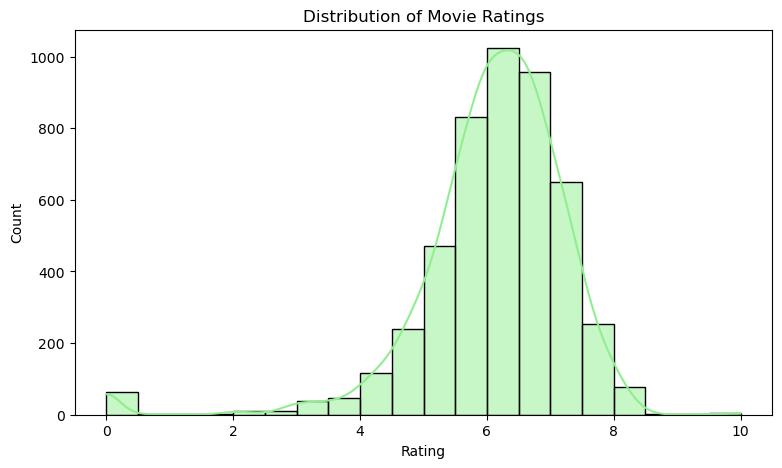

In [17]:
plt.figure(figsize=(9, 5))
sns.histplot(df['vote_average'], bins=20, kde=True, color='lightgreen')
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

## genre popularity heatmap

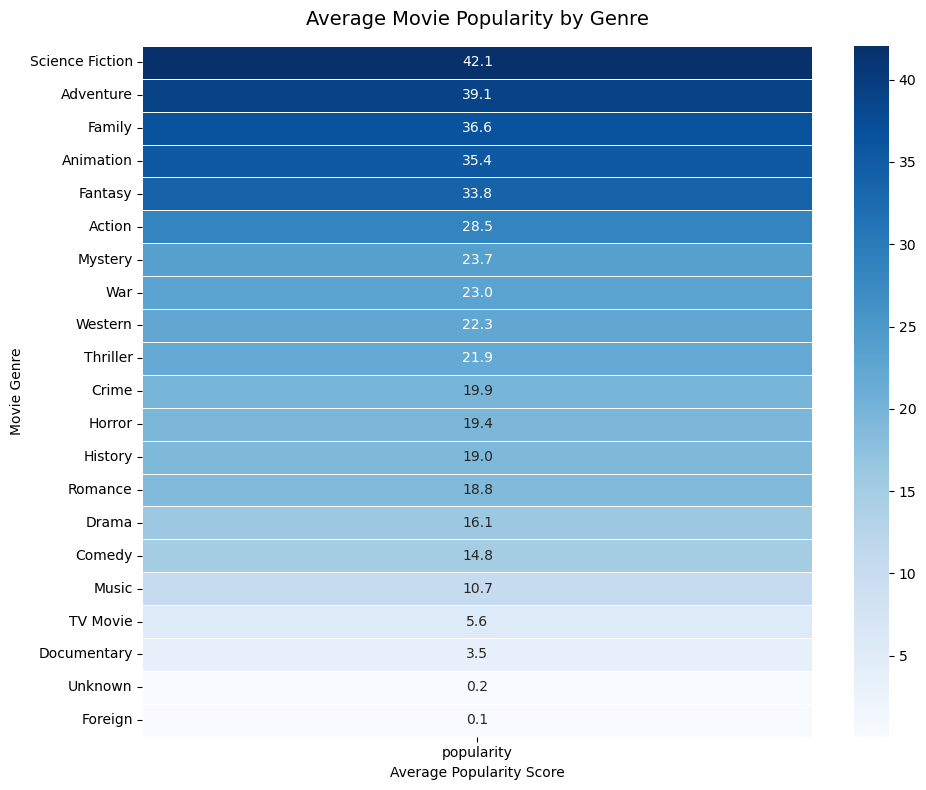

In [18]:
plt.figure(figsize=(10, 8))

sns.heatmap(genre_pivot, annot=True, cmap='Blues', fmt=".1f", linewidths=0.5)

plt.title('Average Movie Popularity by Genre', fontsize=14, pad=15)
plt.ylabel('Movie Genre')
plt.xlabel('Average Popularity Score')
plt.tight_layout()
plt.show()

# Scatter Plot with Interactive Selection

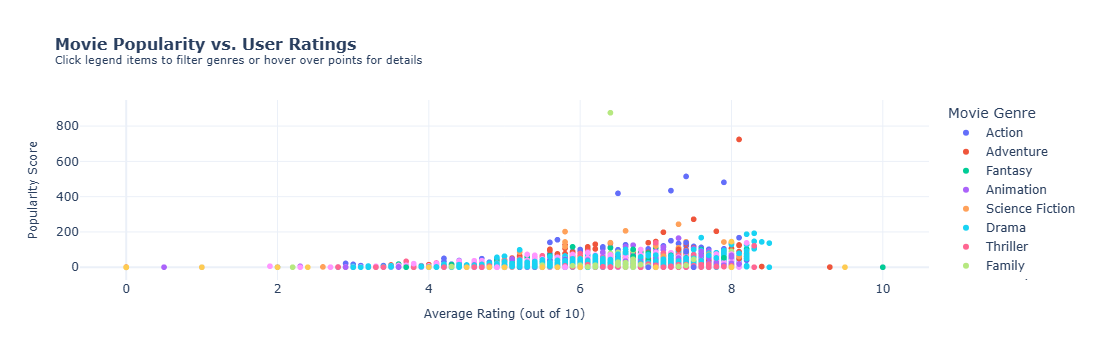

In [20]:
fig = px.scatter(
    df, 
    x='vote_average', 
    y='popularity', 
    color='main_genre',
    hover_name='title', 
    labels={
        'vote_average': 'Average Rating (out of 10)',
        'popularity': 'Popularity Score',
        'main_genre': 'Movie Genre'
    },
    title='<b>Movie Popularity vs. User Ratings</b><br><sup>Click legend items to filter genres or hover over points for details</sup>'
)

fig.update_layout(
    template='plotly_white',
    title_font_size=16,
    xaxis_title_font_size=12,
    yaxis_title_font_size=12
)

fig.show()

fig.write_html("interactive_movie_plot.html")